In [1]:
# testing
import pickle
import numpy as np
import os 
import sys
import json
import matplotlib.pyplot as plt

In [3]:
sys.path.append('/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/Oliveira2024/SCIErlangen/Offline')
from load_emg import load_task

In [15]:
# Load emg, aux, and meta np files for a single action from subject
subject_id = "Subject6"
movement_id = "fist"
# rf"C:\Users\velar\SynologyDrive\Personal\ExperimentalData\0602026Session1\{run_name}\move_{rep:03d}.pkl
emg_raw, aux_data, meta_data = load_task(f"/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/Oliveira2024/SCIErlangen/Offline/{subject_id}", movement_id)
# emg is 256 (n_channels) x 113051 (n_samples)
# fs = 2048
# 'source_file': 'ScJaer20220708122947_05_fist.otb+'

In [61]:
print(meta_data)

{'fs': 2048, 'n_emg': 256, 'n_aux': 1, 'n_ctrl': 8, 'n_samples': 113051, 'duration_s': 55.20068359375, 'ad_bits': 16, 'source_file': 'ScJaer20220708122947_05_fist.otb+', 'grid_ids': ['GR10MM0808', 'GR10MM0808', 'GR08MM1305', 'GR08MM1305'], 'emg_indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,

[[-154 -153 -153 ... -152 -152 -152]]


In [76]:
duration = emg_raw.shape[1] // meta_data['fs']
task_dur_samples = 42 * fs
task_dur_trim_len = emg_raw.shape[1] - task_dur_samples
task_dur_trim = emg_raw[:, task_dur_trim_len : ]
print(emg_raw.shape[1])
print(task_dur_samples)
print(task_dur_trim.shape[1])

113051
86016
86016


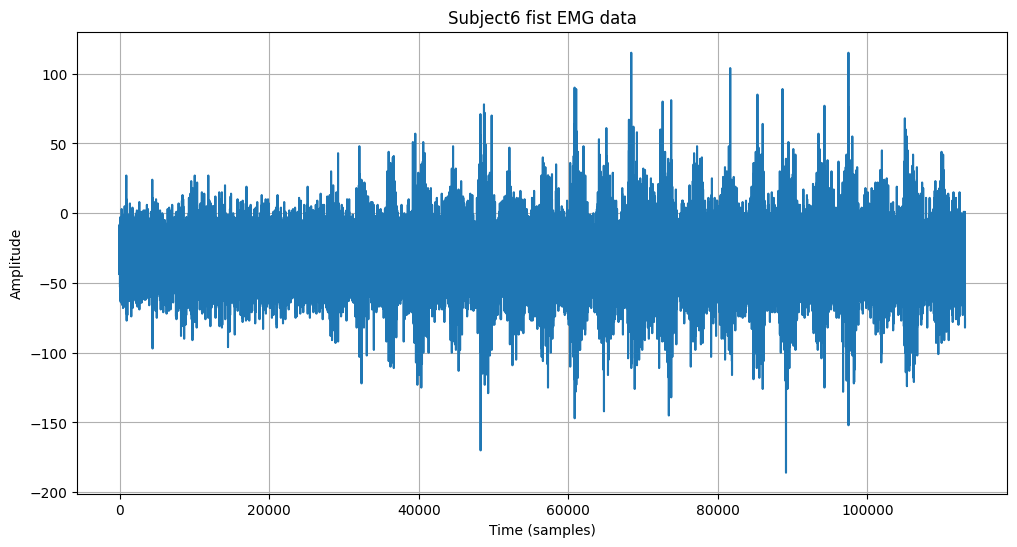

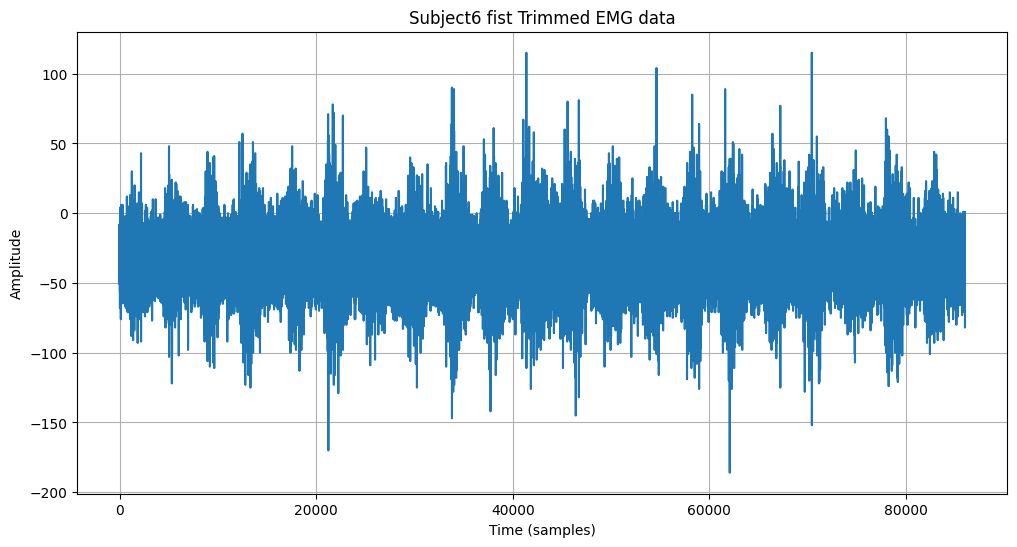

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(emg_raw[5,:])
plt.title(f"{subject_id} {movement_id} EMG data")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(task_dur_trim[5,:])
plt.title(f"{subject_id} {movement_id} Trimmed EMG data")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.grid()



In [18]:
from scipy.interpolate import interp1d

def remove_spikes(emg, threshold_std=5):
    """
    Remove large spikes via simple thresholding and linear interpolation.
    
    Parameters
    ----------
    emg : ndarray, shape (n_channels, n_samples)
    threshold_std : float
        Number of standard deviations for threshold
    
    Returns
    -------
    emg_clean : ndarray
    spike_mask : ndarray, bool
    """
    emg_clean = emg.copy()
    spike_mask = np.zeros_like(emg, dtype=bool)
    
    for ch in range(emg.shape[0]):
        signal = emg[ch]
        threshold = threshold_std * np.std(signal)
        
        spikes = np.abs(signal) > threshold
        spike_mask[ch] = spikes
        
        if np.any(spikes):
            clean_idx = np.where(~spikes)[0]
            spike_idx = np.where(spikes)[0]
            
            if len(clean_idx) > 1:
                interp = interp1d(clean_idx, signal[clean_idx], 
                                  kind='linear', bounds_error=False, 
                                  fill_value='extrapolate')
                emg_clean[ch, spike_idx] = interp(spike_idx)
    
    return emg_clean, spike_mask

In [29]:
emg_data = emg_raw.copy()
emg_clean, spikes = remove_spikes(emg_data, threshold_std=8)

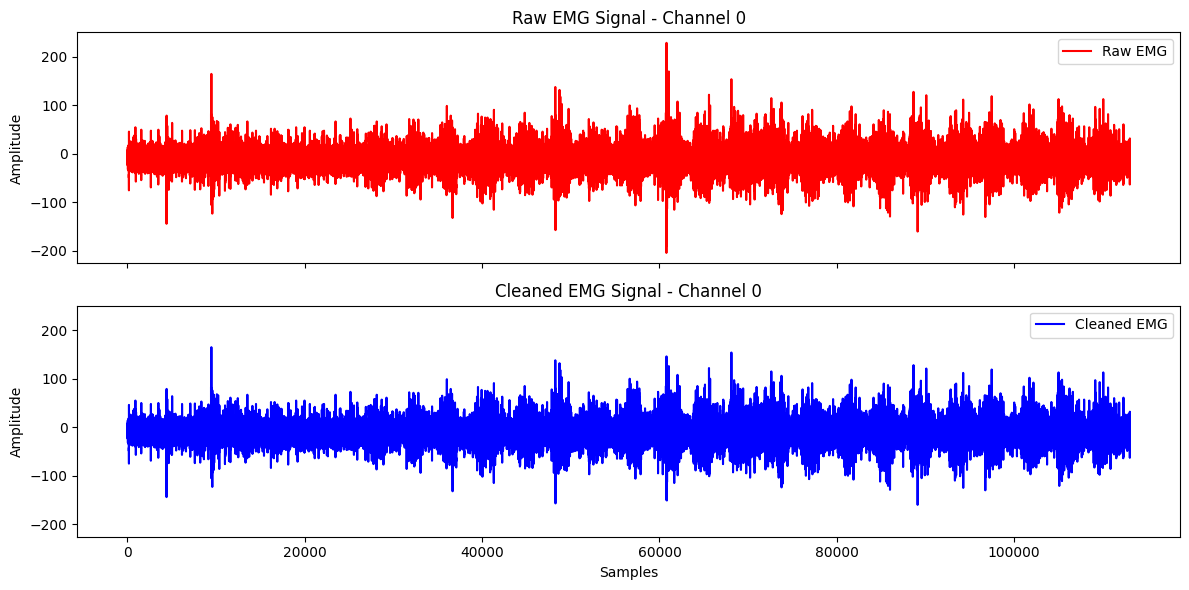

In [21]:
import matplotlib.pyplot as plt
# plot data from first channel with raw and cleaned signal
# use sharex/sharey to keep the same axes between plots to display differences
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

axes[0].plot(emg_raw[0], label='Raw EMG', color='red')
axes[0].set_title('Raw EMG Signal - Channel 0')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(emg_clean[0], label='Cleaned EMG', color='blue')
axes[1].set_title('Cleaned EMG Signal - Channel 0')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
task_dur_trim_clean, spikes = remove_spikes(task_dur_trim, threshold_std=8)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

axes[0].plot(task_dur_trim[0], label='Raw EMG', color='red')
axes[0].set_title('Raw EMG Signal - Channel 0')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(task_dur_trim_clean[0], label='Cleaned EMG', color='blue')
axes[1].set_title('Cleaned EMG Signal - Channel 0')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# Custom modules
sys.path.append('/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/MotorUnitSuite-main/src')
from muniverse.algorithms.decomposition import decompose_cbss
from muniverse.algorithms import cbss

algo_cfg = "/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/MotorUnitSuite-main/src/configs/cbss.json"




In [ ]:
results_full, metadata_full = decompose_cbss(
        data=task_dur_trim_clean,
        algorithm_config=algo_cfg,
        show_config=False, 
)

In [24]:
# The building blocks of the decomposition, straight out of core.py
from src.muniverse.algorithms.core import (
    extension,             # Step 1: add the time lagged copies
    whitening,             # Step 2: decorrelate the extended channels
    est_spike_times,       # Step 4: peak detection + k-means, returns spikes, SIL and centroids
    gram_schmidt,          # Step 7: orthogonalization against the filters already found
    peel_off,              # Step 6: subtract the estimated contribution of a source
    spike_triggered_average,  # The MUAP estimate that peel_off is built on
    cov_isi,               # Coefficient of variation of the inter spike intervals
    remove_duplicates,     # Step 8: keep one source per group of duplicates
    remove_bad_sources,    # Step 8: drop what is below threshold
)

In [35]:
# Data parameters
start_time: int = 0
end_time: int = -1

# EMG preprocessing parameters
fs: int = 2048 


#NOTE: Most signals you will handle are already notched,
#  either by the amplifier itself (Quattrocento/Ripple)
#  or by the recording (In the case of our interface)

notch_params: None   # OPTIONAL: powerline frequency, bandwidth, harmonics:

#NOTE: Ditto as above: in case they are not band passed,
# usual parameters are low pass at 500, high at 20

low_pass_cutoff:int = 500
high_pass_cutoff:int = 20

# Somewhat self explanatory
# There are some automated methods to find bad channels in the repo here and there
# The best one unfortunately remains visual manual inspection
bad_channels: list = []



# Plotting and verbosity
output_source_plot: bool = False
output_final_source_plot: bool = False
verbose_mode: bool = True

In [38]:
extension_factor: int = 16
whitening_method: str = "zca"
ica_n_iter: int= 100
opt_initalization: str = "random"
opt_function_exp:int = 3
opt_max_iter: int =100
opt_tol: float= 1e-4
cluster_method: str = "kmeans"
sil_th: float = 0.85
cov_th: float = 0.35
refinement_loop: bool = True
peel_off: bool = True
fr_peeloff: bool = True

In [36]:
# Extension
R = extension_factor

ext_sig = extension(emg_clean, R)

# Zero mean, one row at a time
ext_sig -= np.mean(ext_sig, axis=1, keepdims=True)

# The edges of the extended array are Toeplitz padding, not signal: blank them
ext_sig[:, : R * 2] = 0
ext_sig[:, -R * 2 :] = 0

print(f"Before extension : {emg_clean.shape}")
print(f"After  extension : {ext_sig.shape}   ({emg_clean.shape[0]} channels x {R} lags)")
print(f"Total lag covered: {R / fs * 1000:.1f} ms")

Before extension : (256, 113051)
After  extension : (4096, 113051)   (256 channels x 16 lags)
Total lag covered: 7.8 ms


Whitened signal : (4096, 113051)
Whitening matrix: (4096, 4096)


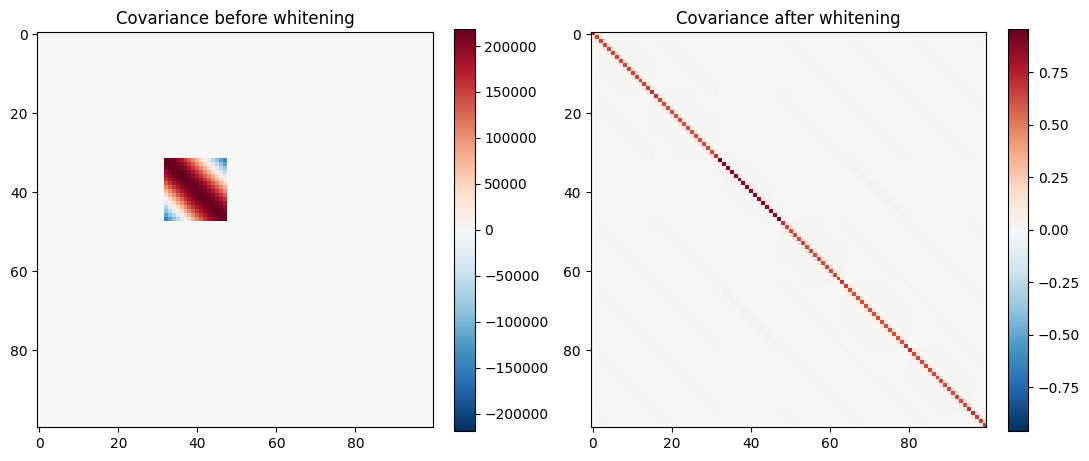

In [39]:
# Whitening
white_sig, Z = whitening(
    Y=ext_sig,
    method=whitening_method.upper(),
    regularization="auto",
)

print(f"Whitened signal : {white_sig.shape}")
print(f"Whitening matrix: {Z.shape}")

##### I don't think I understand where the matrix reduction comes from via whitening #######
##### the non-whitened matrix is 1024 x  30720 while the whitened matrix is 1024 x 1024. #######

# A quick visual check: the covariance should go from "structured" to "identity".
# We only look at the first 100 rows, the full 1024 x 1024 matrix is unreadable

n_show = 100
cov_before = np.cov(ext_sig[:n_show])
cov_after = np.cov(white_sig[:n_show])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cov, title in zip(axes, [cov_before, cov_after],
                          ['Covariance before whitening', 'Covariance after whitening']):
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-np.abs(cov).max(), vmax=np.abs(cov).max())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [40]:
# Fixed point
def fixed_point(w, X, B, exponent=3, tol=1e-4, max_iter=100, deflation="gram-schmidt"):
    """
    Maximize the sparseness of the projection w.T @ X.

    Parameters:
    - w: np.ndarray, the initial separation vector (n_extended_channels,) ## forward model
    - X: np.ndarray, the whitened signal (n_extended_channels x n_samples)
    - B: np.ndarray, the filters (w?) already found, in columns. Used for the deflation
    - exponent: int, the 'a' of the contrast function, i.e. opt_function_exp
    - tol: float, stop when w stops moving by more (**less**??) than this #### How do we set this value??
    - max_iter: int, hard cap on the number of steps
    - deflation: str, how to keep w away from the filters already in B

    Returns:
    - w: np.ndarray, the optimized separation vector
    - k: int, how many iterations it actually took
    """

    # The contrast function and its derivative. ## G(x) and g(x) for negentropy
    # epsilon only keeps the expression differentiable around zero
    epsilon = 1e-3
    a = exponent
    g = lambda x: (epsilon + x**2) ** ((a - 3) / 2) * (a * x**2 + epsilon) ##### Where do these estimations of negentropy come from?? Can't find in Negro 2016
    gp = lambda x: (a - 1) * x * (epsilon + x**2) ** ((a - 5) / 2) * (a * x**2 + 3 * epsilon)

    delta = np.ones(max_iter)
    k = 0

    while delta[k] > tol and k < max_iter - 1:
        w_last = w.copy()

        # The projection of the data on the current filter, i.e. the current source estimate
        wTX = w.T @ X

        # The fixed point update itself
        A = np.mean(gp(wTX))                      ## mean(g'(w.T @ X)) from above text
        w = np.mean(X * g(wTX), axis=1) - A * w   ## w_new             from above text
 
        # Deflation: remove from w everything that lies along the filters we already accepted,
        # otherwise every run would converge onto the same, strongest motor unit
        if deflation == "gram-schmidt":
            w = gram_schmidt(w, B)
        elif deflation == "projection_deflation":
            w = w - (B @ B.T) @ w
            

        # Only the direction of w matters, so we keep it on the unit sphere
        w = w / np.linalg.norm(w)

        # Convergence: 1 minus the dot product between the new and the old direction
        ##### Equals 0 if perfectly converged, we just care if this value is less than our "tol" convergence value
        delta[k + 1] = abs(np.dot(w, w_last) - 1)
        k += 1

    return w, k

Converged in 13 iterations


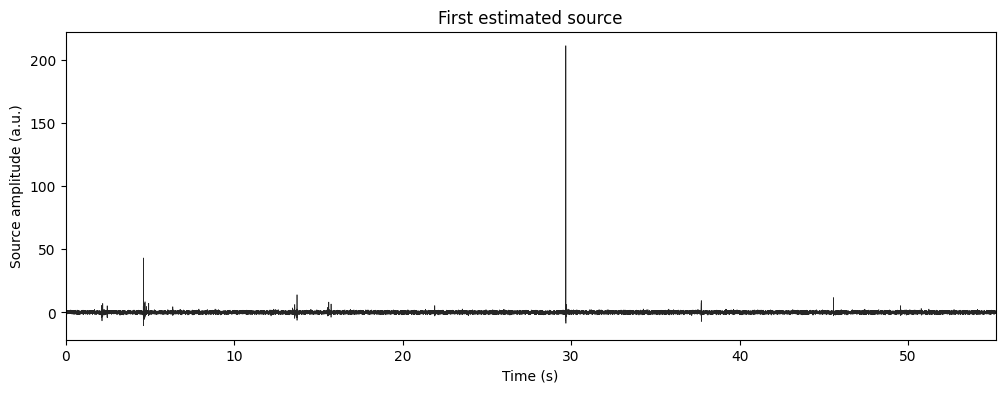

In [41]:
# Reproducibility: the initialization is random, so without a seed you get a different
# source every time you re-run the cell
np.random.seed(1909)

# No filters found yet, so the deflation matrix is empty
mu_filters = np.zeros((white_sig.shape[0], 1))

# 'random' initialization, as set in the configuration section
w = np.random.randn(white_sig.shape[0]) ### begin with a random guess for the weights (mixing/forward model)

w, n_steps = fixed_point(w, white_sig, mu_filters,
                         exponent=opt_function_exp,
                         tol=opt_tol,
                         max_iter=opt_max_iter)

# The source is simply the projection of the whitened data on the filter we just found
source = w.T @ white_sig ### (S = WTX)

print(f"Converged in {n_steps} iterations")

t = np.arange(source.size) / fs
plt.figure(figsize=(12, 4))
plt.plot(t, source, lw=0.5, color='0.15')
plt.xlabel('Time (s)')
plt.ylabel('Source amplitude (a.u.)')
plt.title('First estimated source')
plt.xlim(0, t[-1])
plt.show()

In [42]:
# Spikes
spikes, sil, centroids = est_spike_times(source, fs, cluster=cluster_method)

# Coefficient of variation of the inter spike intervals, and firing rate
cov = cov_isi(spikes, fs)
fr = len(spikes) / (source.size / fs)

print(f"Spikes detected : {len(spikes)}")
print(f"Silhouette (SIL): {sil:.3f}   (threshold: {sil_th})")
print(f"CoV of the ISI  : {cov:.3f}   (threshold: {cov_th})")
print(f"Firing rate     : {fr:.2f} Hz")
print(f"K-means centroids (noise, spike): {np.sort(centroids)}")

Spikes detected : 14
Silhouette (SIL): 0.875   (threshold: 0.85)
CoV of the ISI  : 1.529   (threshold: 0.35)
Firing rate     : 0.25 Hz
K-means centroids (noise, spike): [ 1.23475691 40.59937674]


In [43]:
# Refinement
def minimize_cov_isi(w, X, cov, fsamp, cluster='kmeans'):
    """
    Iteratively rebuild a motor unit filter from its own spike times, as long as
    the coefficient of variation of the inter spike intervals keeps decreasing.

    Parameters:
    - w: np.ndarray, the filter coming out of the fixed point algorithm
    - X: np.ndarray, the whitened signal
    - cov: float, the CoV of the ISI of the current source
    - fsamp: float, sampling frequency in Hz
    - cluster: str, the clustering method passed to est_spike_times

    Returns:
    - w, spikes, cov: the refined filter, its spike train and its CoV
    """

    # Anything larger than cov, so the first round always runs
    cov_last = cov + 1

    while cov < cov_last:
        # Current estimate of the source and of its discharges
        source = w.T @ X
        spikes, _, _ = est_spike_times(source, fsamp, cluster=cluster)

        cov_last = cov
        isi = np.diff(spikes / fsamp)
        cov = np.std(isi) / np.mean(isi)

        # The new filter is the average of the whitened signal at the discharge instants
        w = np.mean(X[:, spikes], axis=1)
        w = w / np.linalg.norm(w)

    return w, spikes, cov
    

In [44]:
if len(spikes) > 10 and refinement_loop:
    w_ref, _, cov_ref = minimize_cov_isi(w, white_sig, cov, fs, cluster=cluster_method)

    # Recompute everything with the refined filter
    source_ref = w_ref.T @ white_sig
    spikes_ref, sil_ref, centroids_ref = est_spike_times(source_ref, fs, cluster=cluster_method)
    fr_ref = len(spikes_ref) / (source_ref.size / fs)

    print(f"{'':<10}{'before':>10}{'after':>10}")
    print(f"{'SIL':<10}{sil:>10.3f}{sil_ref:>10.3f}")
    print(f"{'CoV':<10}{cov:>10.3f}{cov_ref:>10.3f}")
    print(f"{'FR (Hz)':<10}{fr:>10.2f}{fr_ref:>10.2f}")
    print(f"{'Spikes':<10}{len(spikes):>10d}{len(spikes_ref):>10d}")

    # From here on we work with the refined version
    w, source, spikes, sil, cov, centroids = w_ref, source_ref, spikes_ref, sil_ref, cov_ref, centroids_ref
else:
    print("Not enough spikes for the refinement loop, keeping the filter as it is")

              before     after
SIL            0.875     0.929
CoV            1.529     1.529
FR (Hz)         0.25      0.29
Spikes            14        16


In [54]:
from scipy.fft import fft, ifft
waveform = spike_triggered_average(white_sig, spikes, win, fs)

width = int(win * fs)
spikes = spikes[(spikes >= width + 1) & (spikes < white_sig.shape[1] - width - 1)]
firings = np.zeros(white_sig.shape[1])
firings[spikes] = 1

# Zero-pad waveform to match signal shape
L = white_sig.shape[1]
pad_len = L - waveform.shape[1]
waveform_padded = np.pad(waveform, ((0, 0), (0, pad_len)), mode="constant")

# FFT of firings (same for all channels)
fft_firings = fft(firings)

# FFT of waveform for each channel
fft_waveform = fft(waveform_padded, axis=1)

# Multiply in frequency domain (broadcasting firings to each channel)
fft_product = fft_waveform * fft_firings

# IFFT to get time domain component signal
comp_sig = np.real(ifft(fft_product, axis=1))

# Correct time shift due to FFT convolution (center of kernel)
shift = (waveform.shape[1] - 1) // 2
comp_sig = np.roll(comp_sig, -shift, axis=1)

residual_sig = white_sig - comp_sig

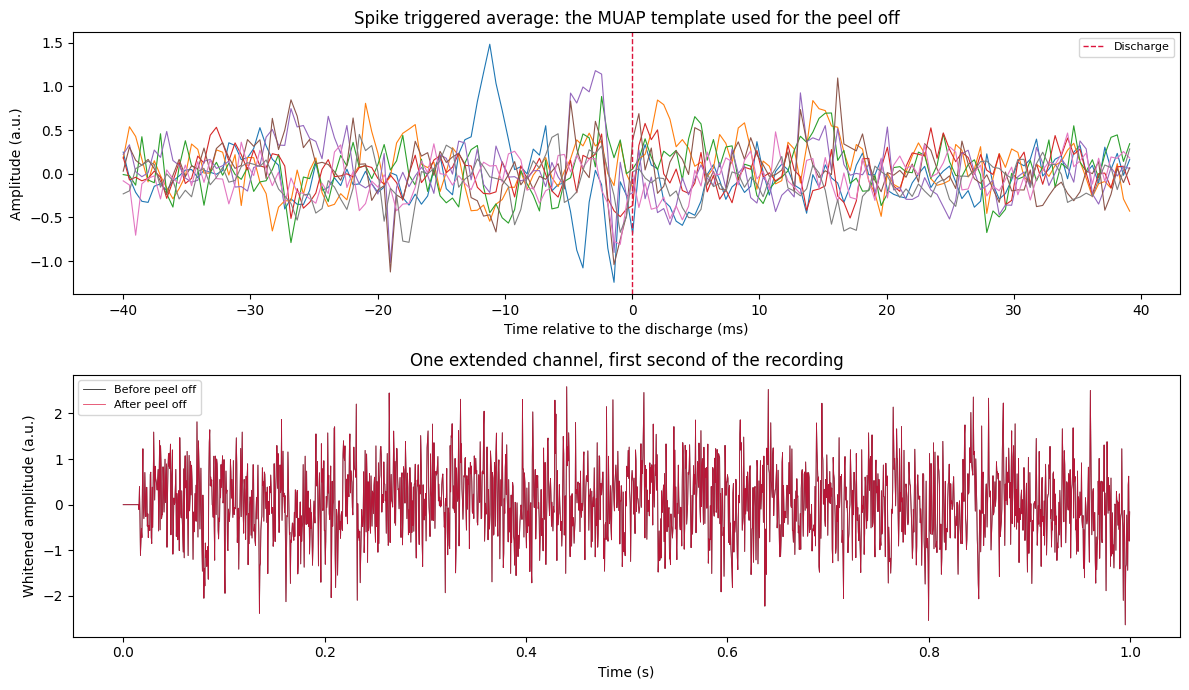

In [55]:
# # Peel off
# # The MUAP estimate: the average of the whitened signal in a window around each discharge
# win = 0.04  # seconds, so 40 ms, wide enough to contain a whole MUAP

# # The actual subtraction. It returns the residual, the reconstructed contribution
# # of this source, and the template it used
# residual_sig, comp_sig, waveform = peel_off(white_sig, spikes, win=win, fsamp=fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Left: the MUAP template on a handful of extended channels
# Note however, the template is calculated on the whitened signal,
# so it is not directly comparable to the original EMG and not make much sense

lag = np.arange(waveform.shape[1]) / fs * 1000 - win * 1000
for ch in range(0, waveform.shape[0], max(1, waveform.shape[0] // 8)):
    axes[0].plot(lag, waveform[ch], lw=0.8)
axes[0].axvline(0, color='crimson', ls='--', lw=1, label='Discharge')
axes[0].set_xlabel('Time relative to the discharge (ms)')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].set_title('Spike triggered average: the MUAP template used for the peel off')
axes[0].legend(fontsize=8)

# Right: one channel, before and after the subtraction, on a short window so it is readable
seg = slice(0, int(1.0 * fs))
axes[1].plot(t[seg], white_sig[0, seg], lw=0.6, color='0.15', label='Before peel off')
axes[1].plot(t[seg], residual_sig[0, seg], lw=0.6, color='crimson', alpha=0.8, label='After peel off')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Whitened amplitude (a.u.)')
axes[1].set_title('One extended channel, first second of the recording')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [58]:
# Load the baseline configuration
REPO_DIR = '/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/MotorUnitSuite-main'
with open(os.path.join(REPO_DIR, 'src', 'configs', 'cbss.json')) as f:
    cbss_config = json.load(f)['Config']

# The JSON stores disabled options as the string "None", turn them back into real None
cbss_config = {k: (None if v == "None" else v) for k, v in cbss_config.items()}

print(json.dumps(cbss_config, indent=2))

{
  "start_time": 0,
  "end_time": -1,
  "sampling_frequency": 2048,
  "bandpass": null,
  "bandpass_order": 2,
  "notch_frequency": 50,
  "notch_n_harmonics": 3,
  "notch_order": 2,
  "notch_width": 1,
  "ext_fact": 16,
  "whitening_method": "ZCA",
  "whitening_reg": "auto",
  "ica_n_iter": 100,
  "opt_initalization": "random",
  "opt_function_exp": 3,
  "opt_max_iter": 100,
  "opt_tol": 0.0001,
  "source_deflation": "gram-schmidt",
  "peel_off": true,
  "fr_peeloff": true,
  "cluster_method": "kmeans",
  "random_seed": 1909,
  "refinement_loop": true,
  "sil_th": 0.85,
  "cov_th": 0.35,
  "verbose_mode": true
}


In [60]:
# Everything from step 1 to step 8, in one call
from src.muniverse.algorithms.cbss import CBSS

decomposer = CBSS(**cbss_config)

sources_cbss, spikes_cbss, sil_cbss, filters_cbss, Z_cbss, centroids_cbss = decomposer.decompose(
    emg_clean, fsamp=fs
)

print(f"\nCBSS found {sources_cbss.shape[0]} motor units, "
      f"our step by step version found {n_mu}")

[INFO] Extending signals by factor 16...

STARTING CBSS DECOMPOSITION
Max iterations: 100, Silhouette threshold: 0.850, CoV threshold: 0.350

Refinement loop for source 0 (initial Sil: 0.875, CoV: 1.529, Spikes: 14)
FR peel-off enabled
Refinement loop for source 1 (initial Sil: 0.969, CoV: 1.132, Spikes: 11)
FR peel-off enabled
Refinement loop for source 2 (initial Sil: 0.888, CoV: 1.404, Spikes: 13)
FR peel-off enabled
FR peel-off enabled
Refinement loop for source 4 (initial Sil: 0.873, CoV: 1.406, Spikes: 13)
FR peel-off enabled
Refinement loop for source 5 (initial Sil: 0.853, CoV: 1.014, Spikes: 15)
FR peel-off enabled
Refinement loop for source 6 (initial Sil: 0.909, CoV: 1.489, Spikes: 14)
FR peel-off enabled
Refinement loop for source 7 (initial Sil: 0.908, CoV: 1.315, Spikes: 11)
FR peel-off enabled
Refinement loop for source 8 (initial Sil: 0.884, CoV: 1.406, Spikes: 13)
FR peel-off enabled
Refinement loop for source 9 (initial Sil: 0.915, CoV: 1.412, Spikes: 11)
FR peel-off 

NameError: name 'n_mu' is not defined